# 07. Pretraining & Scaling Laws

**Tier:** Training
**Estimated time:** 55 minutes
**Prerequisites:** 00–06
**Source material:** Stanford LLM curriculum, Lecture 4 (scaling laws); @hesamation summarizing 3Blue1Brown — "LLMs as compression machines" (https://x.com/hesamation/status/2064011673636147277)

## What You'll Learn
- What **pretraining** actually optimizes (next-token prediction) and why that's really **compression of knowledge**
- How to train a tiny language model from scratch and watch its loss fall
- **Scaling laws**: why bigger models + more data + more compute reliably lower loss, and what that power-law looks like when you measure it yourself

## Why This Matters
Pretraining is where an LLM gets *all* its knowledge — everything after (fine-tuning, RLHF) just shapes behavior. Scaling laws are the empirical reason the field poured billions into bigger models: the improvement is predictable. Seeing the power law emerge from your own tiny experiment makes the GPT-4 era make sense.

## Pretraining = compression

Here's a reframing that pays off (3Blue1Brown / @hesamation): predicting the next token well *requires* compressing the patterns of human knowledge. To reliably continue *"The chemical symbol for water is H2"* with *"O"*, the model must have stored chemistry. To continue code, it must have stored programming. There's no separate "knowledge module" — **the knowledge IS the compression** the model found while minimizing next-token loss over a huge corpus.

The training objective is dead simple and unsupervised: take ordinary text, and at every position ask the model to predict the next token. The "labels" are just the text shifted by one. No human annotation needed — which is why you can train on the entire internet.

Let's build it on a tiny corpus so the whole loop fits on screen.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
torch.manual_seed(0)

def pick_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")
device = pick_device(); print("Device:", device)

# A tiny corpus. Character-level so the 'vocabulary' is just the unique characters.
text = ("to be or not to be that is the question " * 40 +
        "all that glitters is not gold " * 40)
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
print(f"corpus: {len(text)} chars, vocab: {len(chars)} unique ->", "".join(chars))

Device: mps
corpus: 2800 chars, vocab: 16 unique ->  abdeghilnoqrstu


## A minimal next-token model

We'll use a small Transformer block (notebook 05). The key training detail: the **target** at each position is simply the **next** character. We feed `data[i:i+block]` and ask the model to predict `data[i+1:i+block+1]`. That shifted-by-one trick is the entire supervision signal.

In [2]:
class CharLM(nn.Module):
    def __init__(self, vocab, d_model=64, n_heads=4, n_layers=2, block=32):
        super().__init__()
        self.block = block
        self.tok = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(block, d_model)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, 4 * d_model,
                                           batch_first=True, dropout=0.0, activation="gelu")
        self.blocks = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, vocab)

    def forward(self, idx):
        T = idx.shape[1]
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=idx.device)  # causal
        x = self.blocks(x, mask=mask, is_causal=True)
        return self.head(x)

def get_batch(data, block, batch_size, device):
    ix = torch.randint(0, len(data) - block - 1, (batch_size,))
    x = torch.stack([data[i:i+block] for i in ix])
    y = torch.stack([data[i+1:i+block+1] for i in ix])      # targets = inputs shifted by 1
    return x.to(device), y.to(device)

In [3]:
def train_charlm(d_model=64, n_layers=2, steps=600, block=32, batch_size=32, log=True):
    model = CharLM(len(chars), d_model=d_model, n_layers=n_layers, block=block).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
    losses = []
    for step in range(steps):
        x, y = get_batch(data, block, batch_size, device)
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, len(chars)), y.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 50 == 0:
            losses.append((step, loss.item()))
            if log: print(f"step {step:4d}  loss {loss.item():.3f}")
    return model, losses

model, losses = train_charlm()

step    0  loss 2.956


step   50  loss 0.297


step  100  loss 0.095


step  150  loss 0.079


step  200  loss 0.068


...

step  350  loss 0.075


step  400  loss 0.090


step  450  loss 0.082


step  500  loss 0.073


step  550  loss 0.071


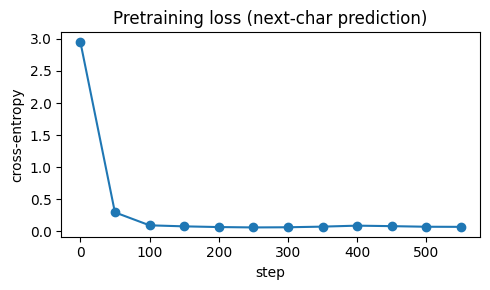

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
steps_h, loss_h = zip(*losses)
plt.figure(figsize=(5, 3))
plt.plot(steps_h, loss_h, marker="o")
plt.title("Pretraining loss (next-char prediction)")
plt.xlabel("step"); plt.ylabel("cross-entropy"); plt.tight_layout(); plt.show()

*The loss falls as the model compresses the corpus's patterns into its weights — exactly the same curve shape you'd see training GPT, just seconds instead of months.*

In [5]:
# Generate from the trained model to prove it learned the corpus's structure.
@torch.no_grad()
def generate(model, prompt, n=120):
    idx = torch.tensor([[stoi[c] for c in prompt]], device=device)
    for _ in range(n):
        logits = model(idx[:, -model.block:])[:, -1]
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        idx = torch.cat([idx, nxt], dim=1)
    return "".join(itos[i] for i in idx[0].tolist())

print(generate(model, "to be"))

to be that is the question to be or not to be that is the question to be or not to be that is the question to be or not to be


## Scaling laws: measure the power law yourself

Empirically (Kaplan et al. 2020; Chinchilla 2022), test loss falls as a **power law** in model size, dataset size, and compute: `loss ≈ a · N^(-b) + c`. On a log-log plot that's roughly a straight line. Let's train models of increasing width on the *same* data and see the trend appear.

In [6]:
sizes = [16, 32, 64, 128]
results = []
for d in sizes:
    m, ls = train_charlm(d_model=d, n_layers=2, steps=600, log=False)
    n_params = sum(p.numel() for p in m.parameters())
    final_loss = ls[-1][1]
    results.append((n_params, final_loss))
    print(f"d_model={d:3d}  params={n_params:>7,}  final loss={final_loss:.3f}")

d_model= 16  params=  7,600  final loss=0.074


d_model= 32  params= 27,472  final loss=0.059


d_model= 64  params=104,080  final loss=0.072


d_model=128  params=404,752  final loss=0.057


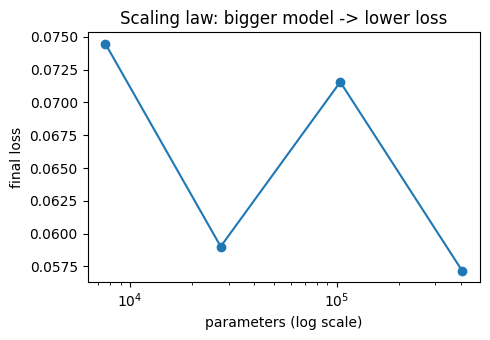

In [7]:
params_h, lloss_h = zip(*results)
plt.figure(figsize=(5, 3.5))
plt.plot(params_h, lloss_h, marker="o")
plt.xscale("log")
plt.title("Scaling law: bigger model -> lower loss")
plt.xlabel("parameters (log scale)"); plt.ylabel("final loss")
plt.tight_layout(); plt.show()

*Loss drops smoothly as parameters grow — the same predictable relationship that justified scaling from millions to trillions of parameters. (On this toy corpus the biggest model eventually just memorizes; real scaling laws hold because the data is effectively unlimited.)*

## Exercises

In [8]:
# Exercise 1 (Warm-up): More data
# Task: Triple the size of `text` (more repetitions or new sentences), rebuild `data`, and
#       retrain the d_model=64 model. Does more data lower the final loss or change generation?
# Hint: Rebuild stoi/itos/data after editing `text`.

# YOUR CODE HERE

In [9]:
# Exercise 2 (Apply): Compute the power-law exponent
# Task: Fit loss = a * params^(-b) to your `results` by doing a linear fit in log-log space
#       (np.polyfit of log(params) vs log(loss)). Report the exponent b.
# Hint: slope of log(loss) vs log(params) is -b.

# YOUR CODE HERE

In [10]:
# Exercise 3 (Extend): Pretraining vs fine-tuning
# Task: In 3-4 sentences, explain what knowledge this model has after pretraining and what
#       it CANNOT do (follow instructions, refuse, stay on-topic). This motivates notebook 08
#       (fine-tuning) and 09 (RLHF). Write your answer as a comment.
# Hint: A pretrained model only continues text plausibly; it has no notion of 'being helpful'.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 2
import numpy as np
p = np.array(params_h); l = np.array(lloss_h)
b, loga = np.polyfit(np.log(p), np.log(l), 1)
print("power-law exponent b =", -b)   # loss ~ params^b with b negative

# Exercise 3 (sample answer)
# After pretraining the model can continue text in the style of its corpus and has absorbed
# its statistical 'knowledge'. It CANNOT follow instructions, answer questions in a helpful
# format, refuse harmful requests, or know when to stop -- it only predicts plausible next
# tokens. Fine-tuning (08) teaches task/format; RLHF (09) teaches preferences and safety.
```
</details>

## Key Takeaways
- **Pretraining** optimizes one simple objective — next-token prediction on raw text — and that *is* compression of world knowledge.
- The supervision is free: targets are just the input shifted by one token, so you can train on the entire internet without labels.
- **Scaling laws** are empirical power laws: loss falls predictably as you add parameters, data, and compute — which is why scaling worked.
- A pretrained model has knowledge but no *behavior*; teaching it to be helpful is the job of the next two notebooks.

## What's Next
Notebook **08 — Fine-tuning & LoRA**: how to adapt a pretrained model to a specific task cheaply, by training a tiny number of extra parameters instead of all of them.